Indices:  [ 0 14]
values:  [0.99997799 2.9999611 ]


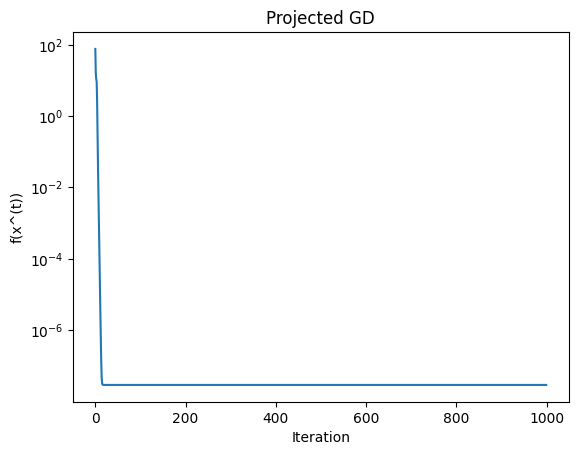

In [21]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('HW7Ab.csv', delimiter=',')
A = data[:, :50]
b = data[:, 50]

m, n = A.shape

def f(x):
    r = A @ x - b
    return 0.5 * np.dot(r, r)

def grad_f(x):
    return A.T @ (A @ x - b)

def proj_B(z, s=2):
    v = np.maximum(z, 0.0)
    y = np.zeros_like(v)
    if s >= len(v):
        return v

    idx = np.argpartition(v, -s)[-s:]
    y[idx] = v[idx]
    return y

s = 2
mu = 0.04
max_iters = 1000

x = np.zeros(n)
f_vals = []

for t in range(max_iters):
    f_vals.append(f(x))

    g = grad_f(x)
    z = x - mu * g
    x = proj_B(z, s=s)

indices = np.where(np.abs(x) > 10**-6)[0]
values  = x[indices]

print("Indices: ", indices)
print("values: ", values)

plt.semilogy(f_vals)
plt.xlabel("Iteration")
plt.ylabel("f(x^(t))")
plt.title("Projected GD")
plt.show()


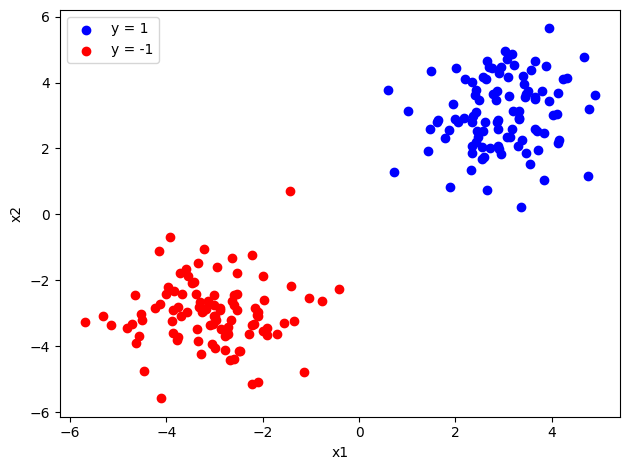

In [24]:
data = np.loadtxt('HW7SVM.csv', delimiter=',')

X = data[:, :2]

y = np.ones(X.shape[0])
y[100:] = -1

X_pos = X[y == 1]
X_neg = X[y == -1]

plt.scatter(X_pos[:, 0], X_pos[:, 1], c='blue', label='y = 1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], c='red',  label='y = -1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
def grad_loss(w, X, y):
    grad = w.copy()
    n = X.shape[0]
    for i in range(n):
        m = 1 - y[i] * np.dot(X[i], w)
        if m > 0:
            grad += -y[i] * X[i]
    return grad

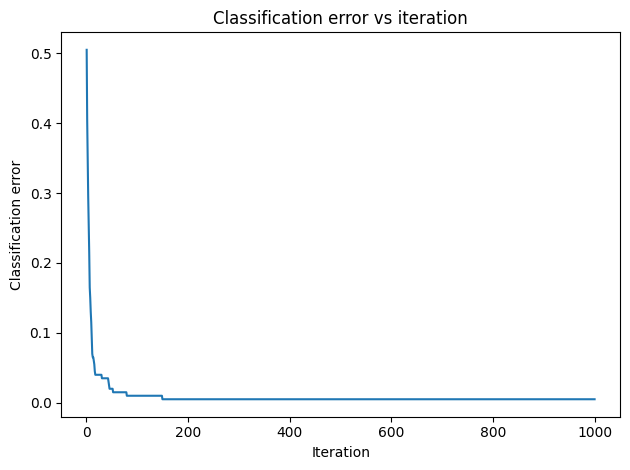

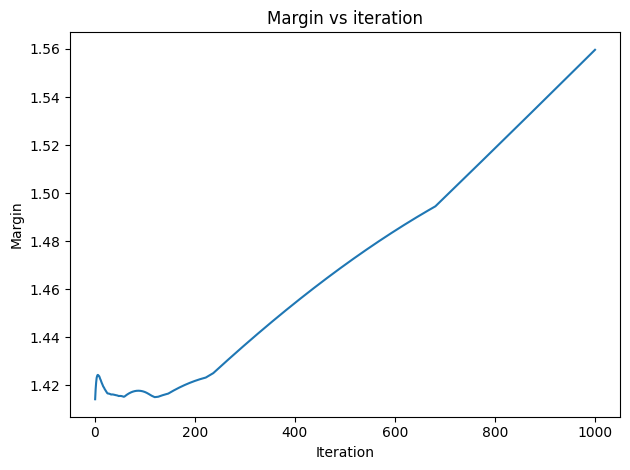

In [27]:
mu = 10**-4
T = 1000
w = np.array([-1.0, 1.0])

errors = np.zeros(T)
margins = np.zeros(T)

for t in range(T):
    scores = X @ w 
    y_pred = np.sign(scores)
    errors[t] = np.mean(y_pred != y)
    margins[t] = 2.0 / np.linalg.norm(w)
    g = grad_loss(w, X, y)
    w = w - mu * g

iters = np.arange(1, T + 1)

plt.plot(iters, errors)
plt.xlabel('Iteration')
plt.ylabel('Classification error')
plt.title('Classification error vs iteration')
plt.tight_layout()

plt.show()

plt.plot(iters, margins)
plt.xlabel('Iteration')
plt.ylabel('Margin')
plt.title('Margin vs iteration')
plt.tight_layout()
plt.show()

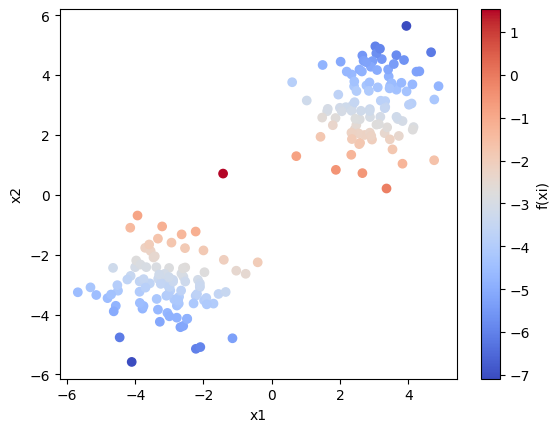

In [29]:
f_vals = 1 - y * (X @ w)
sp = plt.scatter(X[:, 0], X[:, 1], c = f_vals, cmap ='coolwarm')
plt.xlabel('x1')
plt.ylabel('x2')
plt.colorbar(sp, label='f(xi)')
plt.show()
